# Learned Poisson LDS for MC Pacman spiking data

Learn one linear dynamical system per condition with Poisson spike-count observations. Force is held out and decoded from inferred latent states.

## Imports and configuration

In [1]:
from pathlib import Path
import os
import sys
sys.path.append(os.path.abspath(".."))
from utils.data import load_mc_pacman_data, print_data_structure
import pickle

SCRATCH = Path(os.environ.get("SCRATCH", "/farmshare/user_data/vivek772/stats-305c-data"))
os.environ.setdefault("SCRATCH", str(SCRATCH))
DATA_PATH = SCRATCH / "mc_pacman.pkl"
TMP_DIR = SCRATCH / "tmp"
TMP_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("TMPDIR", str(TMP_DIR))
os.environ.setdefault("MPLCONFIGDIR", str(TMP_DIR / "matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

MODEL_DIR = Path(os.environ.get("POISSON_LDS_MODEL_DIR", "models"))
MODEL_DIR.mkdir(parents=True, exist_ok=True)

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display
from plotly.subplots import make_subplots
from jax import vmap
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import r2_score

from dynamax.generalized_gaussian_ssm import GeneralizedGaussianSSM, EKFIntegrals
from dynamax.generalized_gaussian_ssm import conditional_moments_gaussian_smoother as cmgs

BIN_MS = 50
SMOOTH_SIGMA_BINS = 1.0
STATE_DIM = 18
LEARNING_STEPS = 100
LEARNING_RATE = 1e-2
TEST_FRACTION = 0.2
SEED = 7
RIDGE_ALPHAS = np.logspace(-3, 3, 13)


ERROR:2026-05-17 14:35:15,101:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/users/vivek772/miniconda3/envs/dynagpu-env/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/users/vivek772/miniconda3/envs/dynagpu-env/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/users/vivek772/miniconda3/envs/dynagpu-env/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 281, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


## Data loading

In [2]:
data = load_mc_pacman_data()
conditions = np.asarray(data["condition"])
force_trials = data["force"]
spike_trials = data["spikes"]


## Preprocessing

In [3]:
from utils.preprocessing import (
    bin_and_smooth_trials, 
    split_condition_trials, 
    pooled_split_indices,
    standardize_train_test, 
    stack_trials
)


## Poisson LDS learning

In [4]:
from utils.poisson_lds import (
    COV_FLOOR,
    RATE_FLOOR,
    PoissonLDSParams,
    infer_latents,
    infer_latents_grouped,
    learn_poisson_lds,
    learn_poisson_lds_grouped,
    make_poisson_lds_params,
    marginal_log_prob_per_bin,
    poisson_rate,
    predict_expected_counts,
)


def fit_condition_lds(
    cond,
    learning_steps=LEARNING_STEPS,
    state_dim=STATE_DIM,
    seed=SEED,
    bin_ms=BIN_MS,
    smooth_sigma_bins=SMOOTH_SIGMA_BINS,
    learning_rate=LEARNING_RATE,
    test_fraction=TEST_FRACTION,
    verbose=False,
):
    train_idx, test_idx = split_condition_trials(conditions, cond, test_fraction, seed)
    train_spikes = [spike_trials[i] for i in train_idx]
    test_spikes = [spike_trials[i] for i in test_idx]
    train_force = [force_trials[i] for i in train_idx]
    test_force = [force_trials[i] for i in test_idx]

    y_train = bin_and_smooth_trials(train_spikes, bin_ms, 0, "spikes")
    y_test = bin_and_smooth_trials(test_spikes, bin_ms, 0, "spikes")
    f_train = bin_and_smooth_trials(train_force, bin_ms, smooth_sigma_bins, "force")
    f_test = bin_and_smooth_trials(test_force, bin_ms, smooth_sigma_bins, "force")

    y_train_stack = stack_trials(y_train)
    model = GeneralizedGaussianSSM(state_dim=state_dim, emission_dim=y_train_stack.shape[-1])
    key = jr.PRNGKey(seed + 1000 + int(cond))
    trainable_params, params, lls = learn_poisson_lds(
        y_train_stack,
        state_dim=state_dim,
        key=key,
        learning_steps=learning_steps,
        learning_rate=learning_rate,
        verbose=verbose,
    )

    return {
        "condition": int(cond),
        "model": model,
        "params": params,
        "trainable_params": trainable_params,
        "training_log_likelihoods": lls,
        "train_idx": train_idx,
        "test_idx": test_idx,
        "y_train": y_train,
        "y_test": y_test,
        "force_train": f_train,
        "force_test": f_test,
    }


def fit_pooled_lds(
    learning_steps=LEARNING_STEPS,
    state_dim=STATE_DIM,
    seed=SEED,
    bin_ms=BIN_MS,
    smooth_sigma_bins=SMOOTH_SIGMA_BINS,
    learning_rate=LEARNING_RATE,
    test_fraction=TEST_FRACTION,
    verbose=False,
):
    train_idx, test_idx = pooled_split_indices(conditions, test_fraction, seed)
    train_spikes = [spike_trials[i] for i in train_idx]
    test_spikes = [spike_trials[i] for i in test_idx]
    train_force = [force_trials[i] for i in train_idx]
    test_force = [force_trials[i] for i in test_idx]

    y_train = bin_and_smooth_trials(train_spikes, bin_ms, 0, "spikes")
    y_test = bin_and_smooth_trials(test_spikes, bin_ms, 0, "spikes")
    f_train = bin_and_smooth_trials(train_force, bin_ms, smooth_sigma_bins, "force")
    f_test = bin_and_smooth_trials(test_force, bin_ms, smooth_sigma_bins, "force")

    model = GeneralizedGaussianSSM(state_dim=state_dim, emission_dim=y_train[0].shape[-1])
    key = jr.PRNGKey(seed + 2000)
    trainable_params, params, lls = learn_poisson_lds_grouped(
        y_train,
        state_dim=state_dim,
        key=key,
        learning_steps=learning_steps,
        learning_rate=learning_rate,
        verbose=verbose,
    )

    return {
        "condition": "pooled",
        "model": model,
        "params": params,
        "trainable_params": trainable_params,
        "training_log_likelihoods_per_bin": lls,
        "train_idx": train_idx,
        "test_idx": test_idx,
        "condition_train": np.asarray(conditions[train_idx], dtype=int),
        "condition_test": np.asarray(conditions[test_idx], dtype=int),
        "y_train": y_train,
        "y_test": y_test,
        "force_train": f_train,
        "force_test": f_test,
    }


predict_rates = predict_expected_counts


## Evaluation

In [7]:
from functools import partial
from utils.evaluation import (
    evaluate_force_decoding as evaluate_force_decoding_with,
    evaluate_spike_reconstruction as evaluate_spike_reconstruction_with,
    mean_feature_variance_explained as _mean_neuron_variance_explained,
    summarize_fit as summarize_fit_with,
    variance_explained as _variance_explained,
)


def poisson_predict_observations(fit, trials):
    return predict_expected_counts(fit["params"], fit["trainable_params"], trials)


def poisson_infer_latents(fit, trials):
    return infer_latents(fit["params"], trials)


def poisson_marginal_log_prob_per_bin(fit, trials):
    return marginal_log_prob_per_bin(fit["params"], trials)


evaluate_spike_reconstruction = partial(
    evaluate_spike_reconstruction_with,
    predict_observations_fn=poisson_predict_observations,
)
evaluate_force_decoding = partial(
    evaluate_force_decoding_with,
    infer_latents_fn=poisson_infer_latents,
    ridge_alphas=RIDGE_ALPHAS,
)
summarize_fit = partial(
    summarize_fit_with,
    evaluate_spike_reconstruction_fn=evaluate_spike_reconstruction,
    evaluate_force_decoding_fn=evaluate_force_decoding,
    marginal_log_prob_per_bin_fn=poisson_marginal_log_prob_per_bin,
    final_log_likelihood_key="training_log_likelihoods",
    final_log_likelihood_name="final_train_ll",
)


## Model cache helpers


In [8]:
from utils.lds_cache import (
    lds_metadata as make_lds_metadata,
    lds_path as make_lds_path,
    load_or_fit_lds,
    poisson_fit_payload_for_pickle,
    restore_poisson_fit_from_pickle,
)

MODEL_CACHE_VERSION = "poisson_lds_fit_learned_v1"


def lds_metadata(
    kind,
    *,
    learning_steps,
    state_dim,
    seed,
    bin_ms,
    smooth_sigma_bins,
    learning_rate,
    rate_floor,
    cov_floor,
    test_fraction,
    data_path,
    emission_distribution,
    condition=None,
):
    emission_distribution = str(emission_distribution).lower()
    if emission_distribution != "poisson":
        raise ValueError(f"unsupported emission distribution: {emission_distribution}")
    return make_lds_metadata(
        MODEL_CACHE_VERSION,
        kind,
        emission_distribution,
        data_path,
        condition=condition,
        bin_ms=int(bin_ms),
        smooth_sigma_bins=float(smooth_sigma_bins),
        state_dim=int(state_dim),
        learning_steps=int(learning_steps),
        learning_rate=float(learning_rate),
        rate_floor=float(rate_floor),
        cov_floor=float(cov_floor),
        test_fraction=float(test_fraction),
        seed=int(seed),
    )


def lds_path(kind, metadata):
    return make_lds_path(MODEL_DIR, kind, metadata)


def load_or_fit_condition_lds(
    cond,
    learning_steps=LEARNING_STEPS,
    state_dim=STATE_DIM,
    seed=SEED,
    bin_ms=BIN_MS,
    smooth_sigma_bins=SMOOTH_SIGMA_BINS,
    learning_rate=LEARNING_RATE,
    rate_floor=RATE_FLOOR,
    cov_floor=COV_FLOOR,
    test_fraction=TEST_FRACTION,
    data_path=DATA_PATH,
    emission_distribution="poisson",
    verbose=False,
):
    metadata = lds_metadata(
        "condition_lds",
        learning_steps=learning_steps,
        state_dim=state_dim,
        seed=seed,
        bin_ms=bin_ms,
        smooth_sigma_bins=smooth_sigma_bins,
        learning_rate=learning_rate,
        rate_floor=rate_floor,
        cov_floor=cov_floor,
        test_fraction=test_fraction,
        data_path=data_path,
        emission_distribution=emission_distribution,
        condition=cond,
    )
    path = lds_path("condition_lds", metadata)
    return load_or_fit_lds(
        path,
        metadata,
        lambda: fit_condition_lds(
            cond=int(cond),
            learning_steps=learning_steps,
            state_dim=state_dim,
            seed=seed,
            bin_ms=bin_ms,
            smooth_sigma_bins=smooth_sigma_bins,
            learning_rate=learning_rate,
            test_fraction=test_fraction,
            verbose=verbose,
        ),
        poisson_fit_payload_for_pickle,
        restore_poisson_fit_from_pickle,
    )


## Smoke fit

In [ ]:
smoke_fit = load_or_fit_condition_lds(cond=1, learning_steps=5, state_dim=STATE_DIM, seed=SEED, verbose=False)
smoke_summary = summarize_fit(smoke_fit)
pd.DataFrame([smoke_summary])

## Pooled all-condition LDS

Train one additional Poisson LDS on the union of all condition-specific training trials. Trials have different time lengths across conditions, so pooled training groups trials by binned duration instead of stacking all trials into one rectangular tensor.


In [9]:
def load_or_fit_pooled_lds(
    learning_steps=LEARNING_STEPS,
    state_dim=STATE_DIM,
    seed=SEED,
    bin_ms=BIN_MS,
    smooth_sigma_bins=SMOOTH_SIGMA_BINS,
    learning_rate=LEARNING_RATE,
    rate_floor=RATE_FLOOR,
    cov_floor=COV_FLOOR,
    test_fraction=TEST_FRACTION,
    data_path=DATA_PATH,
    emission_distribution="poisson",
    verbose=False,
):
    metadata = lds_metadata(
        "pooled_lds",
        learning_steps=learning_steps,
        state_dim=state_dim,
        seed=seed,
        bin_ms=bin_ms,
        smooth_sigma_bins=smooth_sigma_bins,
        learning_rate=learning_rate,
        rate_floor=rate_floor,
        cov_floor=cov_floor,
        test_fraction=test_fraction,
        data_path=data_path,
        emission_distribution=emission_distribution,
    )
    path = lds_path("pooled_lds", metadata)
    return load_or_fit_lds(
        path,
        metadata,
        lambda: fit_pooled_lds(
            learning_steps=learning_steps,
            state_dim=state_dim,
            seed=seed,
            bin_ms=bin_ms,
            smooth_sigma_bins=smooth_sigma_bins,
            learning_rate=learning_rate,
            test_fraction=test_fraction,
            verbose=verbose,
        ),
        poisson_fit_payload_for_pickle,
        restore_poisson_fit_from_pickle,
    )


def expected_counts_from_latents_grouped(trainable_params, latents):
    groups = {}
    for i, z in enumerate(latents):
        groups.setdefault(z.shape[0], []).append((i, z))
    expected = [None] * len(latents)
    for n_bins in sorted(groups):
        indices, zs = zip(*groups[n_bins])
        z_stack = jnp.asarray(np.stack(zs), dtype=jnp.float64)
        expected_stack = np.asarray(vmap(vmap(lambda z: poisson_rate(trainable_params, z)))(z_stack))
        for local_i, trial_i in enumerate(indices):
            expected[trial_i] = expected_stack[local_i]
    return expected


def cache_pooled_inferences(pooled_fit):
    for split in ["train", "test"]:
        latents = infer_latents_grouped(pooled_fit["params"], pooled_fit[f"y_{split}"])
        expected = expected_counts_from_latents_grouped(pooled_fit["trainable_params"], latents)
        for y, y_hat in zip(pooled_fit[f"y_{split}"], expected):
            if y_hat.shape != y.shape or not np.all(np.isfinite(y_hat)) or np.any(y_hat < 0):
                raise FloatingPointError(f"invalid pooled expected count with shape {y_hat.shape}; expected {y.shape}")
        pooled_fit[f"latent_{split}"] = latents
        pooled_fit[f"expected_{split}"] = expected
    return pooled_fit


def _pooled_latents(pooled_fit, split):
    key = f"latent_{split}"
    if key not in pooled_fit:
        pooled_fit[key] = infer_latents_grouped(pooled_fit["params"], pooled_fit[f"y_{split}"])
    return pooled_fit[key]


def _pooled_expected_counts(pooled_fit, split):
    key = f"expected_{split}"
    if key not in pooled_fit:
        pooled_fit[key] = expected_counts_from_latents_grouped(pooled_fit["trainable_params"], _pooled_latents(pooled_fit, split))
    return pooled_fit[key]


def pooled_spike_variance_by_condition(pooled_fit, split):
    predictions = _pooled_expected_counts(pooled_fit, split)
    split_conditions = np.asarray(pooled_fit[f"condition_{split}"], dtype=int)
    rows = []
    for cond in sorted(np.unique(split_conditions)):
        mask = split_conditions == cond
        y_true = np.concatenate([y for y, keep in zip(pooled_fit[f"y_{split}"], mask) if keep], axis=0)
        y_hat = np.concatenate([y for y, keep in zip(predictions, mask) if keep], axis=0)
        mean_neuron_ve, n_valid = _mean_neuron_variance_explained(y_true, y_hat)
        rows.append(
            {
                "condition": int(cond),
                "split": split,
                "n_trials": int(mask.sum()),
                "n_bins_total": int(y_true.shape[0]),
                "spike_var_explained": float(_variance_explained(y_true, y_hat)),
                "spike_var_explained_mean_neuron": mean_neuron_ve,
                "spike_var_explained_n_neurons": n_valid,
            }
        )
    return pd.DataFrame(rows)


def pooled_spike_variance_overall(pooled_fit, split):
    predictions = _pooled_expected_counts(pooled_fit, split)
    y_true = np.concatenate(pooled_fit[f"y_{split}"], axis=0)
    y_hat = np.concatenate(predictions, axis=0)
    mean_neuron_ve, n_valid = _mean_neuron_variance_explained(y_true, y_hat)
    return {
        "split": split,
        "n_trials": len(pooled_fit[f"y_{split}"]),
        "n_bins_total": int(y_true.shape[0]),
        "spike_var_explained": float(_variance_explained(y_true, y_hat)),
        "spike_var_explained_mean_neuron": mean_neuron_ve,
        "spike_var_explained_n_neurons": n_valid,
    }


def fit_pooled_force_linear_decoder(pooled_fit):
    z_train = np.concatenate(_pooled_latents(pooled_fit, "train"), axis=0)
    f_train = np.concatenate(pooled_fit["force_train"], axis=0).ravel()
    decoder = LinearRegression().fit(z_train, f_train)
    return decoder


def pooled_force_r2_by_condition(pooled_fit, decoder, split):
    latents = _pooled_latents(pooled_fit, split)
    split_conditions = np.asarray(pooled_fit[f"condition_{split}"], dtype=int)
    rows = []
    for cond in sorted(np.unique(split_conditions)):
        mask = split_conditions == cond
        z = np.concatenate([z_trial for z_trial, keep in zip(latents, mask) if keep], axis=0)
        f = np.concatenate([force for force, keep in zip(pooled_fit[f"force_{split}"], mask) if keep], axis=0).ravel()
        pred = decoder.predict(z)
        rows.append(
            {
                "condition": int(cond),
                "split": split,
                "n_trials": int(mask.sum()),
                "force_r2": float(r2_score(f, pred)),
            }
        )
    return pd.DataFrame(rows)


def fit_condition_force_decoders(fits):
    decoders = {}
    rows = []
    for cond in sorted(fits):
        fit = fits[cond]
        params = fit["params"]
        z_train = np.concatenate(infer_latents(params, fit["y_train"]), axis=0)
        f_train = np.concatenate(fit["force_train"], axis=0).ravel()
        z_test = np.concatenate(infer_latents(params, fit["y_test"]), axis=0)
        f_test = np.concatenate(fit["force_test"], axis=0).ravel()
        decoder = RidgeCV(alphas=RIDGE_ALPHAS).fit(z_train, f_train)
        decoders[cond] = decoder
        rows.append(
            {
                "condition": int(cond),
                "force_r2": float(r2_score(f_test, decoder.predict(z_test))),
                "force_alpha": float(decoder.alpha_),
            }
        )
    return decoders, pd.DataFrame(rows)


def plot_decoder_weights(weights, ax, title):
    latent = np.arange(1, len(weights) + 1)
    ax.bar(latent, weights, color=np.where(weights >= 0, "tab:blue", "tab:red"), alpha=0.8)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(title)
    ax.set_xlabel("latent dimension")
    ax.set_ylabel("linear weight")


### Vary dimensions runs


In [11]:
# Fit and save condition-specific Poisson LDS models over several state dimensions.
# Edit this list to control which latent dimensionalities are cached.
STATE_DIMS_TO_FIT = [8, 12, 18]
CONDITIONS_TO_FIT = sorted(int(cond) for cond in np.unique(conditions))

condition_model_grid = {}
for state_dim in STATE_DIMS_TO_FIT:
    condition_model_grid[state_dim] = {}
    for cond in CONDITIONS_TO_FIT:
        condition_model_grid[state_dim][cond] = load_or_fit_condition_lds(
            cond=cond,
            learning_steps=LEARNING_STEPS,
            state_dim=state_dim,
            seed=SEED,
            bin_ms=BIN_MS,
            smooth_sigma_bins=SMOOTH_SIGMA_BINS,
            learning_rate=LEARNING_RATE,
            rate_floor=RATE_FLOOR,
            cov_floor=COV_FLOOR,
            test_fraction=TEST_FRACTION,
            data_path=DATA_PATH,
            emission_distribution="poisson",
            verbose=False,
        )


loading model parameters models/condition_lds_poisson_cond1_bin50_state8_steps100_seed7.pkl
loading model parameters models/condition_lds_poisson_cond2_bin50_state8_steps100_seed7.pkl
loading model parameters models/condition_lds_poisson_cond3_bin50_state8_steps100_seed7.pkl


loading model parameters models/condition_lds_poisson_cond4_bin50_state8_steps100_seed7.pkl
loading model parameters models/condition_lds_poisson_cond5_bin50_state8_steps100_seed7.pkl
loading model parameters models/condition_lds_poisson_cond6_bin50_state8_steps100_seed7.pkl
loading model parameters models/condition_lds_poisson_cond7_bin50_state8_steps100_seed7.pkl
loading model parameters models/condition_lds_poisson_cond8_bin50_state8_steps100_seed7.pkl
loading model parameters models/condition_lds_poisson_cond1_bin50_state12_steps100_seed7.pkl
loading model parameters models/condition_lds_poisson_cond2_bin50_state12_steps100_seed7.pkl
loading model parameters models/condition_lds_poisson_cond3_bin50_state12_steps100_seed7.pkl
loading model parameters models/condition_lds_poisson_cond4_bin50_state12_steps100_seed7.pkl
loading model parameters models/condition_lds_poisson_cond5_bin50_state12_steps100_seed7.pkl
loading model parameters models/condition_lds_poisson_cond6_bin50_state12_s

In [10]:
# Fit and save pooled Poisson LDS models over the same state dimensions.
pooled_model_grid = {}
STATE_DIMS_TO_FIT = [8, 12, 18]
for state_dim in STATE_DIMS_TO_FIT:
    pooled_model_grid[state_dim] = load_or_fit_pooled_lds(
        learning_steps=LEARNING_STEPS,
        state_dim=state_dim,
        seed=SEED,
        bin_ms=BIN_MS,
        smooth_sigma_bins=SMOOTH_SIGMA_BINS,
        learning_rate=LEARNING_RATE,
        rate_floor=RATE_FLOOR,
        cov_floor=COV_FLOOR,
        test_fraction=TEST_FRACTION,
        data_path=DATA_PATH,
        emission_distribution="poisson",
        verbose=False,
    )


loading model parameters models/pooled_lds_poisson_bin50_state8_steps100_seed7.pkl
loading model parameters models/pooled_lds_poisson_bin50_state12_steps100_seed7.pkl
loading model parameters models/pooled_lds_poisson_bin50_state18_steps100_seed7.pkl


In [9]:
pooled_fit = load_or_fit_pooled_lds(learning_steps=LEARNING_STEPS, state_dim=STATE_DIM, seed=SEED, verbose=False)
cache_pooled_inferences(pooled_fit)
pooled_spike_by_condition = pd.concat(
    [pooled_spike_variance_by_condition(pooled_fit, split) for split in ["train", "test"]],
    ignore_index=True,
)
pooled_spike_overall = pd.DataFrame([pooled_spike_variance_overall(pooled_fit, split) for split in ["train", "test"]])
pooled_force_decoder = fit_pooled_force_linear_decoder(pooled_fit)
pooled_force_r2 = pd.concat(
    [pooled_force_r2_by_condition(pooled_fit, pooled_force_decoder, split) for split in ["train", "test"]],
    ignore_index=True,
)

pooled_spike_overall


loading cached model models/pooled_lds_bin50_state18_steps100_seed7.pkl


,split,n_trials,n_bins_total,spike_var_explained,spike_var_explained_mean_neuron,spike_var_explained_n_neurons
0,train,289,24581,0.368996,0.256136,128
1,test,73,6222,0.363421,0.251570,128


### Pooled LDS spike-count variance explained


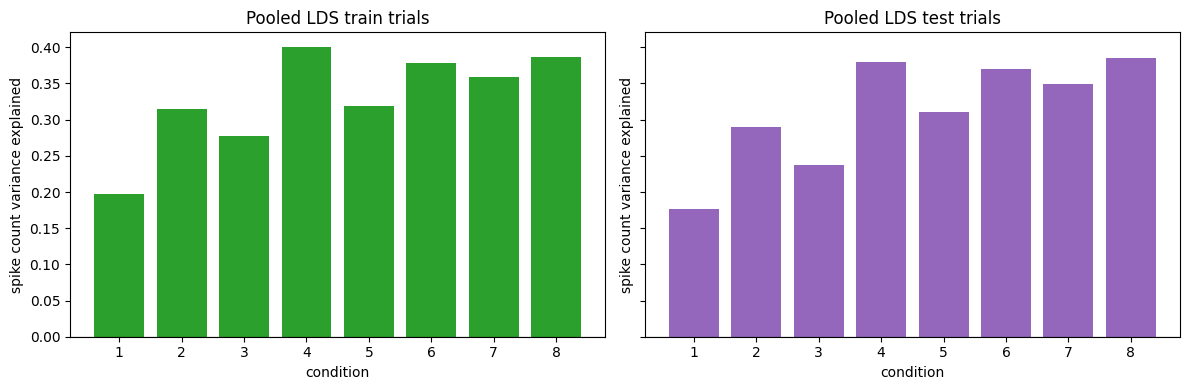

,condition,split,n_trials,n_bins_total,spike_var_explained,spike_var_explained_mean_neuron,spike_var_explained_n_neurons
0,1,train,30,3600,0.197823,0.138531,126
1,2,train,28,3360,0.314148,0.176828,126
2,3,train,30,1350,0.277094,0.159154,126
3,4,train,30,1350,0.400634,0.183232,128
4,5,train,29,3480,0.318503,0.195542,128
5,6,train,34,2720,0.377697,0.231032,128
6,7,train,49,3234,0.358956,0.216680,128
7,8,train,59,5487,0.386926,0.238938,128
8,1,test,8,960,0.176629,0.125874,123
9,2,test,7,840,0.289962,0.154878,126


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, split in zip(axes, ["train", "test"]):
    df = pooled_spike_by_condition.query("split == @split")
    ax.bar(df["condition"], df["spike_var_explained"], color="tab:green" if split == "train" else "tab:purple")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(f"Pooled LDS {split} trials")
    ax.set_xlabel("condition")
    ax.set_ylabel("spike count variance explained")
plt.tight_layout()
plt.show()

pooled_spike_by_condition


### Pooled LDS force decoding


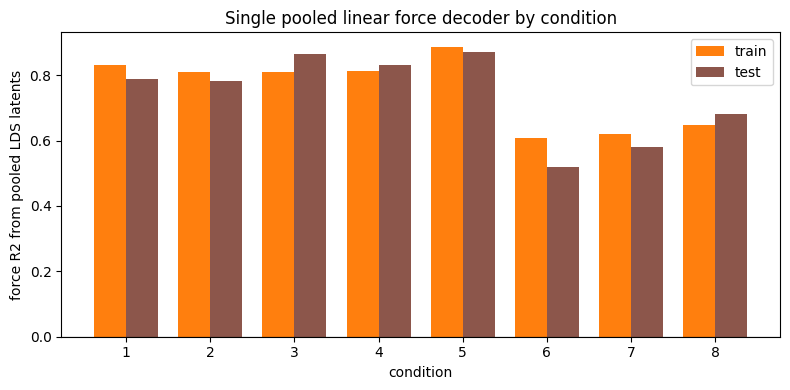

,condition,split,n_trials,force_r2
0,1,train,30,0.832278
1,2,train,28,0.810964
2,3,train,30,0.808373
3,4,train,30,0.813960
4,5,train,29,0.886477
5,6,train,34,0.607857
6,7,train,49,0.621264
7,8,train,59,0.647085
8,1,test,8,0.787980
9,2,test,7,0.780833


In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
width = 0.38
conds = np.asarray(sorted(pooled_force_r2["condition"].unique()), dtype=float)
for offset, split, color in [(-width / 2, "train", "tab:orange"), (width / 2, "test", "tab:brown")]:
    df = pooled_force_r2.query("split == @split").sort_values("condition")
    ax.bar(df["condition"].to_numpy(dtype=float) + offset, df["force_r2"], width=width, label=split, color=color)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(conds)
ax.set_xlabel("condition")
ax.set_ylabel("force R2 from pooled LDS latents")
ax.set_title("Single pooled linear force decoder by condition")
ax.legend()
plt.tight_layout()
plt.show()

pooled_force_r2


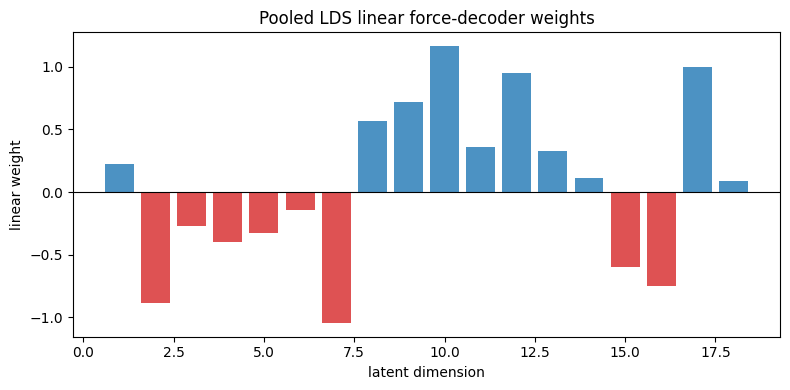

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_decoder_weights(np.asarray(pooled_force_decoder.coef_, dtype=float), ax, "Pooled LDS linear force-decoder weights")
plt.tight_layout()
plt.show()


## Full per-condition run

In [13]:
print(jax.default_backend())
print(jax.devices())

gpu
[CudaDevice(id=0)]


In [14]:
fits = {}
rows = []
for cond in sorted(np.unique(conditions)):
    fit = load_or_fit_condition_lds(cond=int(cond), learning_steps=LEARNING_STEPS, state_dim=STATE_DIM, seed=SEED, verbose=False)
    fits[int(cond)] = fit
    rows.append(summarize_fit(fit))

results = pd.DataFrame(rows).sort_values("condition").reset_index(drop=True)
results

loading cached model models/condition_lds_cond1_bin50_state18_steps100_seed7.pkl
loading cached model models/condition_lds_cond2_bin50_state18_steps100_seed7.pkl
loading cached model models/condition_lds_cond3_bin50_state18_steps100_seed7.pkl
loading cached model models/condition_lds_cond4_bin50_state18_steps100_seed7.pkl
loading cached model models/condition_lds_cond5_bin50_state18_steps100_seed7.pkl
loading cached model models/condition_lds_cond6_bin50_state18_steps100_seed7.pkl
loading cached model models/condition_lds_cond7_bin50_state18_steps100_seed7.pkl
loading cached model models/condition_lds_cond8_bin50_state18_steps100_seed7.pkl


,condition,n_train,n_test,n_bins,final_train_ll,train_ll_per_bin,test_ll_per_bin,spike_var_explained,spike_var_explained_mean_neuron,spike_var_explained_n_neurons,force_r2,force_alpha
0,1,30,8,120,-7557.806005,-62.977693,-64.433603,0.168147,0.128108,123,0.930793,31.622777
1,2,28,7,120,-8073.932128,-67.278958,-67.392411,0.289444,0.155011,126,0.949654,10.000000
2,3,30,8,45,-3047.748240,-67.735834,-72.785726,0.267272,0.183924,125,0.954585,31.622777
3,4,30,7,45,-3093.520046,-68.733641,-72.750580,0.375070,0.177798,122,0.927918,10.000000
4,5,29,7,120,-8596.784165,-71.635272,-73.150780,0.304091,0.178192,127,0.909634,31.622777
5,6,34,9,80,-6417.351846,-80.212033,-82.845081,0.379011,0.215864,127,0.873425,3.162278
6,7,49,12,66,-5539.007481,-83.890275,-85.626363,0.352294,0.225254,127,0.848328,3.162278
7,8,59,15,93,-7517.236789,-80.823150,-82.710451,0.375415,0.238806,128,0.875012,3.162278


### Per-condition force-decoder weights


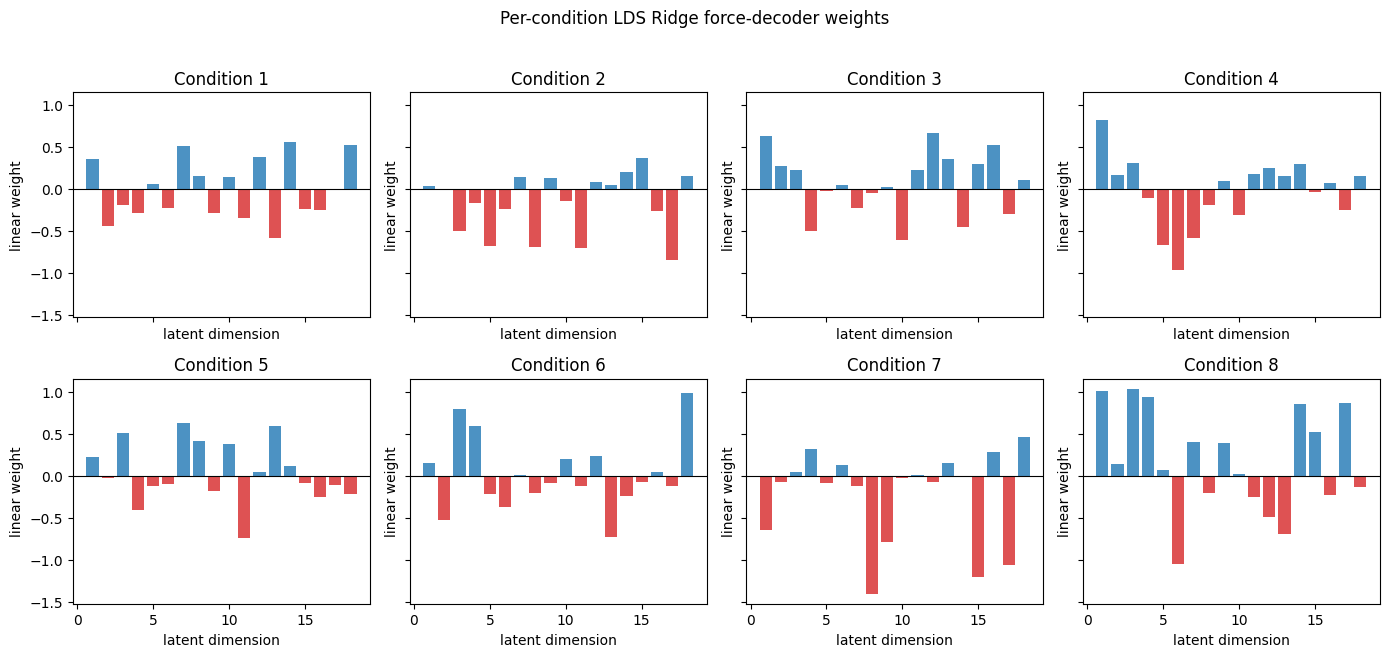

,condition,force_r2,force_alpha
0,1,0.930793,31.622777
1,2,0.949654,10.000000
2,3,0.954585,31.622777
3,4,0.927918,10.000000
4,5,0.909634,31.622777
5,6,0.873425,3.162278
6,7,0.848328,3.162278
7,8,0.875012,3.162278


In [15]:
condition_force_decoders, condition_force_decoder_summary = fit_condition_force_decoders(fits)

n_conditions = len(condition_force_decoders)
n_cols = 4
n_rows = int(np.ceil(n_conditions / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.2 * n_rows), sharex=True, sharey=True)
axes = np.asarray(axes).ravel()
for ax, cond in zip(axes, sorted(condition_force_decoders)):
    weights = np.asarray(condition_force_decoders[cond].coef_, dtype=float)
    plot_decoder_weights(weights, ax, f"Condition {cond}")
for ax in axes[n_conditions:]:
    ax.axis("off")
fig.suptitle("Per-condition LDS Ridge force-decoder weights", y=1.02)
plt.tight_layout()
plt.show()

condition_force_decoder_summary


## Results summary plots

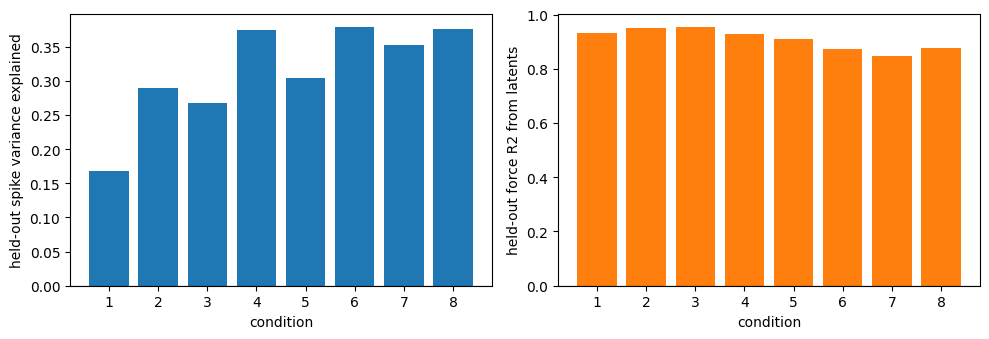

,condition,n_train,n_test,n_bins,final_train_ll,train_ll_per_bin,test_ll_per_bin,spike_var_explained,spike_var_explained_mean_neuron,spike_var_explained_n_neurons,force_r2,force_alpha
0,1,30,8,120,-7557.806005,-62.977693,-64.433603,0.168147,0.128108,123,0.930793,31.622777
1,2,28,7,120,-8073.932128,-67.278958,-67.392411,0.289444,0.155011,126,0.949654,10.000000
2,3,30,8,45,-3047.748240,-67.735834,-72.785726,0.267272,0.183924,125,0.954585,31.622777
3,4,30,7,45,-3093.520046,-68.733641,-72.750580,0.375070,0.177798,122,0.927918,10.000000
4,5,29,7,120,-8596.784165,-71.635272,-73.150780,0.304091,0.178192,127,0.909634,31.622777
5,6,34,9,80,-6417.351846,-80.212033,-82.845081,0.379011,0.215864,127,0.873425,3.162278
6,7,49,12,66,-5539.007481,-83.890275,-85.626363,0.352294,0.225254,127,0.848328,3.162278
7,8,59,15,93,-7517.236789,-80.823150,-82.710451,0.375415,0.238806,128,0.875012,3.162278


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].bar(results["condition"], results["spike_var_explained"])
axes[0].set_xlabel("condition")
axes[0].set_ylabel("held-out spike variance explained")
axes[0].axhline(0, color="black", lw=0.8)

axes[1].bar(results["condition"], results["force_r2"], color="tab:orange")
axes[1].set_xlabel("condition")
axes[1].set_ylabel("held-out force R2 from latents")
axes[1].axhline(0, color="black", lw=0.8)
plt.tight_layout()
plt.show()

results

## Learning convergence

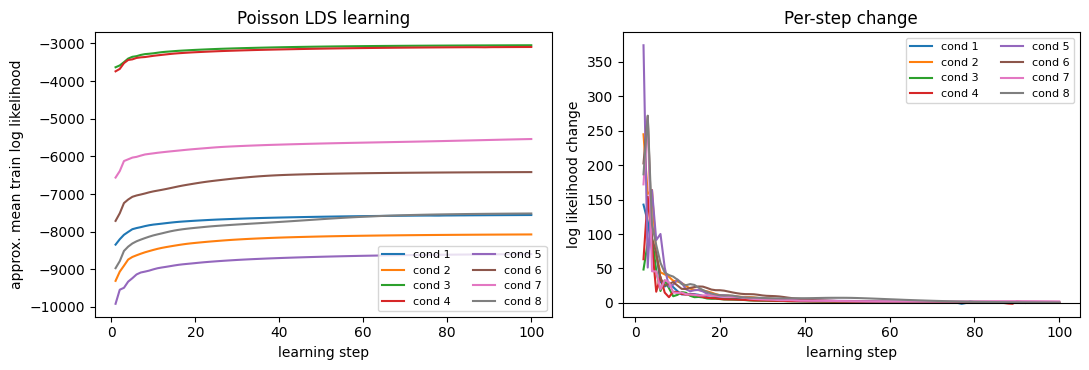

In [17]:
def plot_learning_convergence(fits):
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    for cond in sorted(fits):
        lls = np.asarray(fits[cond]["training_log_likelihoods"], dtype=float)
        if not np.all(np.isfinite(lls)):
            raise ValueError(f"fits[{cond}]['training_log_likelihoods'] contains non-finite values")

        steps = np.arange(1, lls.size + 1)
        axes[0].plot(steps, lls, label=f"cond {cond}")
        if lls.size > 1:
            axes[1].plot(steps[1:], np.diff(lls), label=f"cond {cond}")

    axes[0].set_xlabel("learning step")
    axes[0].set_ylabel("approx. mean train log likelihood")
    axes[0].set_title("Poisson LDS learning")
    axes[0].legend(ncol=2, fontsize=8)

    axes[1].axhline(0, color="black", lw=0.8)
    axes[1].set_xlabel("learning step")
    axes[1].set_ylabel("log likelihood change")
    axes[1].set_title("Per-step change")
    axes[1].legend(ncol=2, fontsize=8)
    plt.tight_layout()
    return fig, axes


plot_learning_convergence(fits)
plt.show()

## Interactive neural dynamics and prediction plots

In [18]:
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import HTML, display
from plotly.subplots import make_subplots


def _split_trials(fit, split):
    if split not in {"train", "test"}:
        raise ValueError("split must be 'train' or 'test'")
    return fit[f"y_{split}"], fit[f"force_{split}"]


def _time_ms(n_bins):
    return np.arange(n_bins) * BIN_MS


def _trial_data(fit, split, trial_number):
    y_trials, force_trials_for_split = _split_trials(fit, split)
    if trial_number < 0 or trial_number >= len(y_trials):
        raise ValueError(f"trial_number must be in [0, {len(y_trials) - 1}] for condition {fit['condition']} {split}")

    y = np.asarray(y_trials[trial_number], dtype=float)
    force = np.asarray(force_trials_for_split[trial_number], dtype=float).reshape(y.shape[0], -1)
    if force.shape[0] != y.shape[0]:
        raise ValueError(f"force and spike counts have different time lengths: {force.shape[0]} vs {y.shape[0]}")
    return y, force[:, 0]


def _latent_and_expected_counts(fit, y):
    params = fit["params"]
    trainable_params = fit["trainable_params"]
    posterior = cmgs(params, EKFIntegrals(), jnp.asarray(y))
    z = np.asarray(posterior.smoothed_means)
    expected = np.asarray(vmap(lambda state: poisson_rate(trainable_params, state))(jnp.asarray(z)))
    if expected.shape != y.shape or not np.all(np.isfinite(expected)) or np.any(expected < 0):
        raise FloatingPointError(f"invalid Poisson expected count with shape {expected.shape}; expected {y.shape}")
    return z, expected


def _population_count(y):
    return np.asarray(y, dtype=float).sum(axis=1)


def _averaged_condition_data(fit, split="test"):
    y_trials, force_trials_for_split = _split_trials(fit, split)
    latents = []
    observed_counts = []
    expected_counts = []
    forces = []

    for y, force in zip(y_trials, force_trials_for_split):
        y = np.asarray(y, dtype=float)
        force = np.asarray(force, dtype=float).reshape(y.shape[0], -1)[:, 0]
        z, expected = _latent_and_expected_counts(fit, y)
        latents.append(z)
        observed_counts.append(_population_count(y))
        expected_counts.append(_population_count(expected))
        forces.append(force)

    return {
        "latent": np.mean(np.stack(latents), axis=0),
        "observed_count": np.mean(np.stack(observed_counts), axis=0),
        "expected_count": np.mean(np.stack(expected_counts), axis=0),
        "force": np.mean(np.stack(forces), axis=0),
    }


def _condition_options(fits):
    return [(f"condition {cond}", cond) for cond in sorted(fits)]


def _global_trial_index(fit, split, trial_number):
    idx = np.asarray(fit.get(f"{split}_idx", np.arange(len(fit[f"y_{split}"]))))
    return int(idx[trial_number])


def _trial_title(condition, split, trial_number, global_trial):
    return f"Condition {condition} {split} trial {trial_number} (dataset idx {global_trial})"


def _trial_options(fit, split):
    return [(f"trial {i} (dataset idx {_global_trial_index(fit, split, i)})", i) for i in range(len(fit[f"y_{split}"]))]


def _condition_trial_controls(fits, split):
    condition = widgets.Dropdown(options=_condition_options(fits), description="condition")
    trial = widgets.Dropdown(options=_trial_options(fits[condition.value], split), description="trial")

    def update_trials(change):
        options = _trial_options(fits[change["new"]], split)
        with trial.hold_trait_notifications():
            trial.options = options
            trial.value = options[0][1]

    condition.observe(update_trials, names="value")
    return condition, trial


def _show_plot(fig):
    fig.update_layout(template="plotly_white", hovermode="x unified", height=620)
    display(HTML(fig.to_html(full_html=False, include_plotlyjs="cdn")))


def plot_single_trial_latents_and_force(fits, split="test"):
    condition, trial = _condition_trial_controls(fits, split)

    def render(condition, trial):
        fit = fits[condition]
        y, force = _trial_data(fit, split, trial)
        z, _ = _latent_and_expected_counts(fit, y)
        t_ms = _time_ms(y.shape[0])
        global_trial = _global_trial_index(fit, split, trial)
        trial_title = _trial_title(condition, split, trial, global_trial)

        fig = make_subplots(
            rows=2,
            cols=1,
            shared_xaxes=True,
            vertical_spacing=0.08,
            subplot_titles=(
                f"{trial_title}: latent dimensions",
                "Force",
            ),
        )
        for dim in range(z.shape[1]):
            fig.add_trace(go.Scatter(x=t_ms, y=z[:, dim], mode="lines", name=f"z{dim}"), row=1, col=1)
        fig.add_trace(go.Scatter(x=t_ms, y=force, mode="lines", name="force", line=dict(color="black")), row=2, col=1)
        fig.update_yaxes(title_text="latent state", row=1, col=1)
        fig.update_yaxes(title_text="force", row=2, col=1)
        fig.update_xaxes(title_text="time (ms)", row=2, col=1)
        _show_plot(fig)

    output = widgets.interactive_output(render, {"condition": condition, "trial": trial})
    display(widgets.VBox([widgets.HBox([condition, trial]), output]))


def plot_trial_averaged_latents_and_force(fits, split="test"):
    condition = widgets.Dropdown(options=_condition_options(fits), description="condition")

    def render(condition):
        fit = fits[condition]
        avg = _averaged_condition_data(fit, split=split)
        z = avg["latent"]
        t_ms = _time_ms(z.shape[0])

        fig = make_subplots(
            rows=2,
            cols=1,
            shared_xaxes=True,
            vertical_spacing=0.08,
            subplot_titles=(
                f"Condition {condition} {split} trial-averaged latent dimensions",
                f"Condition {condition} {split} trial-averaged force",
            ),
        )
        for dim in range(z.shape[1]):
            fig.add_trace(go.Scatter(x=t_ms, y=z[:, dim], mode="lines", name=f"z{dim}"), row=1, col=1)
        fig.add_trace(go.Scatter(x=t_ms, y=avg["force"], mode="lines", name="force", line=dict(color="black")), row=2, col=1)
        fig.update_yaxes(title_text="latent state", row=1, col=1)
        fig.update_yaxes(title_text="force", row=2, col=1)
        fig.update_xaxes(title_text="time (ms)", row=2, col=1)
        _show_plot(fig)

    output = widgets.interactive_output(render, {"condition": condition})
    display(widgets.VBox([condition, output]))


def plot_single_trial_population_counts(fits, split="test"):
    condition, trial = _condition_trial_controls(fits, split)

    def render(condition, trial):
        fit = fits[condition]
        y, _ = _trial_data(fit, split, trial)
        _, expected = _latent_and_expected_counts(fit, y)
        t_ms = _time_ms(y.shape[0])
        global_trial = _global_trial_index(fit, split, trial)
        trial_title = _trial_title(condition, split, trial, global_trial)

        fig = go.Figure()
        fig.add_trace(go.Scatter(x=t_ms, y=_population_count(y), mode="lines", name="observed population count/bin"))
        fig.add_trace(
            go.Scatter(
                x=t_ms,
                y=_population_count(expected),
                mode="lines",
                name="predicted population expected count/bin",
                line=dict(dash="dash"),
            )
        )
        fig.update_layout(title=f"{trial_title}: observed vs predicted population counts")
        fig.update_xaxes(title_text="time (ms)")
        fig.update_yaxes(title_text=f"population spike count per {BIN_MS} ms bin")
        _show_plot(fig)

    output = widgets.interactive_output(render, {"condition": condition, "trial": trial})
    display(widgets.VBox([widgets.HBox([condition, trial]), output]))


def plot_trial_averaged_population_counts(fits, split="test"):
    condition = widgets.Dropdown(options=_condition_options(fits), description="condition")

    def render(condition):
        avg = _averaged_condition_data(fits[condition], split=split)
        t_ms = _time_ms(avg["observed_count"].shape[0])

        fig = go.Figure()
        fig.add_trace(go.Scatter(x=t_ms, y=avg["observed_count"], mode="lines", name="trial-averaged observed population count/bin"))
        fig.add_trace(
            go.Scatter(
                x=t_ms,
                y=avg["expected_count"],
                mode="lines",
                name="trial-averaged predicted population expected count/bin",
                line=dict(dash="dash"),
            )
        )
        fig.update_layout(title=f"Condition {condition} {split} trial-averaged observed vs predicted population counts")
        fig.update_xaxes(title_text="time (ms)")
        fig.update_yaxes(title_text=f"population spike count per {BIN_MS} ms bin")
        _show_plot(fig)

    output = widgets.interactive_output(render, {"condition": condition})
    display(widgets.VBox([condition, output]))


In [19]:
plot_single_trial_latents_and_force(fits, split="train")

In [20]:
plot_single_trial_latents_and_force(fits, split="test")


In [21]:
plot_trial_averaged_latents_and_force(fits, split="test")


In [22]:
plot_single_trial_population_counts(fits, split="train")


In [23]:
plot_single_trial_population_counts(fits, split="test")

In [ ]:
plot_trial_averaged_population_counts(fits, split="test")